**Library Importing**

In [69]:
import kagglehub
import os
import cv2
import shutil
import random
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import Sequential,layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [70]:
# Download latest version
# path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
path = "C:/Users/User/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2"
path = path+"/chest_xray"

print("Path to dataset files:", path)

Path to dataset files: C:/Users/User/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray


In [71]:
train_path = path+"/train"

# Step 1: Count images in each class
normal_images = os.listdir(os.path.join(train_path, "NORMAL"))
pneumonia_images = os.listdir(os.path.join(train_path, "PNEUMONIA"))

n_normal = len(normal_images)
n_pneumonia = len(pneumonia_images)
print(f"Number of NORMAL images: {n_normal}")
print(f"Number of PNEUMONIA images: {n_pneumonia}")

Number of NORMAL images: 1341
Number of PNEUMONIA images: 3875


In [72]:
# Paths
#train path
balanced_train_path = path + "/train_balanced"

# Class folders
classes = ["NORMAL", "PNEUMONIA"]
os.makedirs(balanced_train_path, exist_ok=True)


target_count = min(n_normal, n_pneumonia)

print(f"Balancing to {target_count} images per class.")

# Step 2: Sample and copy
for cls in classes:
    src_dir = os.path.join(train_path, cls)
    dst_dir = os.path.join(balanced_train_path, cls)
    os.makedirs(dst_dir, exist_ok=True)

    images = os.listdir(src_dir)
    sampled = random.sample(images, target_count)

    for img in sampled:
        src_path = os.path.join(src_dir, img)
        dst_path = os.path.join(dst_dir, img)
        shutil.copy(src_path, dst_path)

print("✅ Balanced training folder created at:", balanced_train_path)


Balancing to 1341 images per class.
✅ Balanced training folder created at: C:/Users/User/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/train_balanced


In [73]:
test_path = path+"/test"

# Just rescaling, no splitting
test_datagen = ImageDataGenerator(rescale=1./255)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)


# Load from separate folders
train_generator = train_datagen.flow_from_directory(
    path + "/train_balanced",
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 4691 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


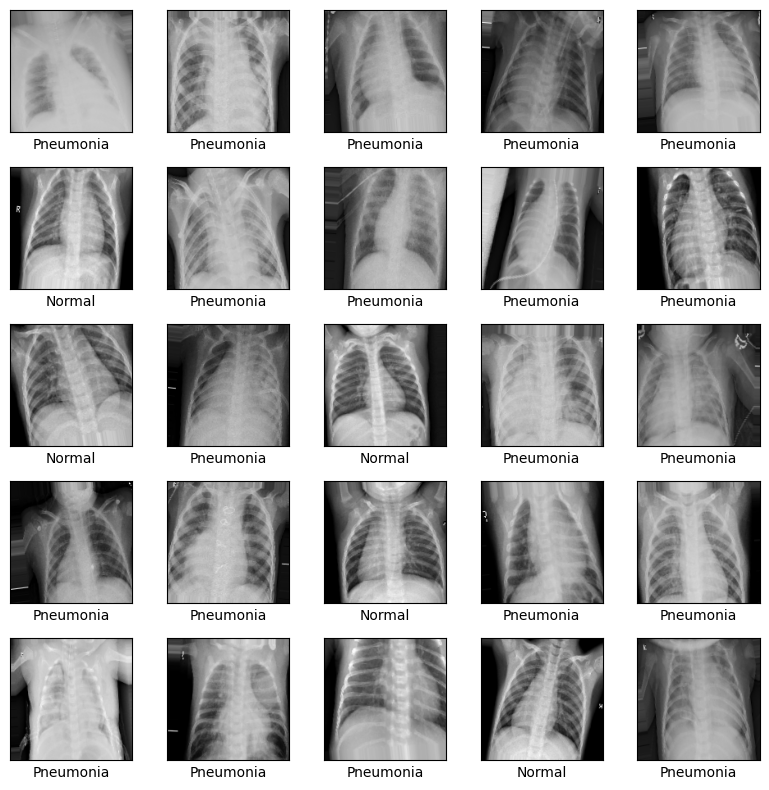

In [82]:
images, labels = next(train_generator)
plt.figure(figsize=(8,8))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(images[i])
  plt.xlabel("Pneumonia" if labels[i] == 1 else "Normal")
plt.tight_layout()
plt.savefig('augmented_images.png')
plt.show()

In [75]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model = models.Sequential([
    layers.Input(shape=(150,150,3)),
    data_augmentation,

    layers.Conv2D(4,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(8,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(8,activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(1,activation='sigmoid')
    ])
model.summary

<bound method Model.summary of <Sequential name=sequential_36, built=True>>

In [76]:
model.compile(optimizer = 'adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=(False)),
              metrics=['accuracy'])


history = model.fit(train_generator, epochs=15,batch_size=32,
                    validation_data=(test_generator))

Epoch 1/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.7118 - loss: 0.6025 - val_accuracy: 0.6250 - val_loss: 0.5945
Epoch 2/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 61s 412ms/step - accuracy: 0.7141 - loss: 0.5119 - val_accuracy: 0.6250 - val_loss: 0.5173
Epoch 3/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 62s 422ms/step - accuracy: 0.7141 - loss: 0.4658 - val_accuracy: 0.6250 - val_loss: 0.4844
Epoch 4/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 64s 433ms/step - accuracy: 0.7517 - loss: 0.4482 - val_accuracy: 0.7837 - val_loss: 0.4688
Epoch 5/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 78s 408ms/step - accuracy: 0.7902 - loss: 0.4496 - val_accuracy: 0.7051 - val_loss: 0.5486
Epoch 6/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 60s 406ms/step - accuracy: 0.8024 - loss: 0.4374 - val_accuracy: 0.7724 - val_loss: 0.5204
Epoch 7/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 62s 424ms/step - accuracy: 0.8179 - loss: 0.4159 - val_accuracy: 0.7756 - val_loss: 0.5018
Epoch 8/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 125s 854ms/step - accuracy: 0.8239 - loss: 0.

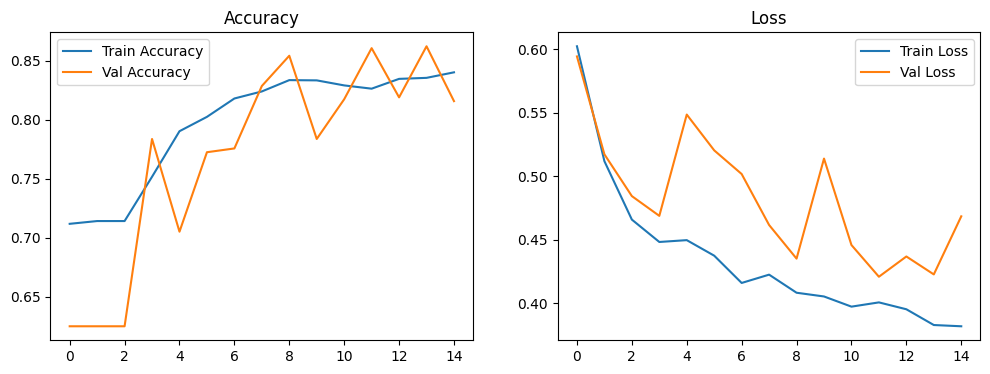

In [79]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.savefig('accuracy_loss.png')
plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 260ms/step
              precision    recall  f1-score   support

      Normal       0.87      0.60      0.71       234
   Pneumonia       0.80      0.95      0.87       390

    accuracy                           0.82       624
   macro avg       0.83      0.77      0.79       624
weighted avg       0.82      0.82      0.81       624



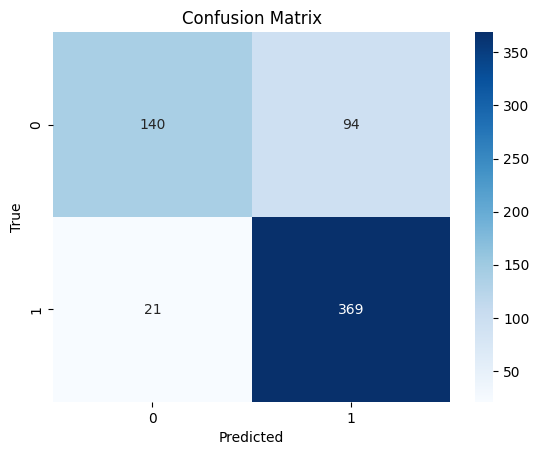

In [81]:
y_pred = model.predict(test_generator)
y_pred = (y_pred > 0.5).astype(int).flatten()
y_true = test_generator.classes

report = classification_report(y_true, y_pred ,target_names=['Normal', 'Pneumonia'])
print(report)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

